# Remplacez la Q-table par un cerveau neuronal (DQN)


In [1]:
import torch.nn as nn
import torch.nn.functional as F

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super().__init__()
        self.layer1 = nn.Linear(n_observations, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, n_actions)
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)


In [2]:
import random
from collections import deque, namedtuple


# Structure nommée pour organiser les expériences stockées dans le buffer
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    
    def __len__(self):
        return len(self.memory)


## Étape 2 — Boucle d'entraînement DQN

In [3]:
import gymnasium as gym
import math
import matplotlib
import matplotlib.pyplot as plt
from itertools import count

import torch
import torch.optim as optim

env = gym.make("CartPole-v1")

is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# Sélection automatique du device : GPU (cuda) > puce Apple (mps) > CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"Device utilisé : {device}")

Device utilisé : cpu


In [4]:
BATCH_SIZE = 128   # Nombre d'expériences tirées du buffer à chaque mise à jour
GAMMA = 0.99       # Facteur d'actualisation : pondère l'importance des récompenses futures
EPS_START = 0.9    # Epsilon initial : forte exploration au départ
EPS_END = 0.01     # Epsilon minimal : l'agent exploite presque toujours ce qu'il a appris
EPS_DECAY = 2500   # Vitesse de décroissance d'epsilon (en nombre de pas)
TAU = 0.005        # Taux de mise à jour douce du target network
LR = 3e-4          # Learning rate de l'optimiseur

n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

# policy_net : le réseau qu'on entraîne à chaque étape
policy_net = DQN(n_observations, n_actions).to(device)
# target_net : copie figée de policy_net, mise à jour lentement pour stabiliser l'apprentissage
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

steps_done = 0

### Choisir une action avec `select_action`: explorer ou exploiter ?

À chaque pas, l'agent doit décider : tester une action au hasard (explorer) ou faire confiance à ce qu'il a appris (exploiter) ? C'est le dilemme exploration/exploitation.

Cette fonction implémente la stratégie **epsilon-greedy** : on tire un nombre aléatoire entre 0 et 1, et on le compare à un seuil epsilon. Si le nombre est en dessous du seuil, on explore (action aléatoire) ; sinon, on exploite (meilleure action selon le réseau).

Epsilon décroît exponentiellement au fil des pas : au début l'agent explore beaucoup car il ne sait rien, puis il exploite de plus en plus à mesure qu'il apprend.

In [5]:
def select_action(state):
    global steps_done
    sample = random.random()
    # Epsilon décroît exponentiellement : exploration au début, exploitation ensuite
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1

    if sample > eps_threshold:
        # Exploitation : action avec la Q-value la plus haute selon policy_net
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        # Exploration : action aléatoire
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

### Visualiser la progression de l'apprentissage avec `plot_durations`

Affiche la durée de chaque épisode (combien de pas avant que le mât tombe). Plus la durée augmente, mieux l'agent joue. La courbe brute est souvent très bruitée, donc on superpose une moyenne glissante sur 100 épisodes pour voir la tendance réelle.

In [6]:
episode_durations = []

def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Résultat final')
    else:
        plt.clf()
        plt.title('Entraînement en cours...')
    plt.xlabel('Épisode')
    plt.ylabel('Durée')
    plt.plot(durations_t.numpy())
    # Moyenne glissante sur 100 épisodes pour lisser la courbe
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())
    plt.pause(0.001)
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

### Le cœur de l'apprentissage DQN avec `optimize_model`

C'est ici que le réseau apprend vraiment. À chaque appel, on tire un batch d'expériences aléatoires dans le buffer et on met à jour `policy_net` pour que ses prédictions se rapprochent des valeurs cibles.

Ces valeurs cibles sont calculées avec l'**équation de Bellman** :

> Q_cible(s, a) = r + γ · max_a' Q(s', a')

Autrement dit : la valeur d'une action dans un état, c'est la récompense immédiate plus la meilleure valeur possible dans l'état suivant, actualisée par γ.

Le point clé : on utilise `target_net` (et non `policy_net`) pour estimer Q(s', a'). Sans ça, la cible change à chaque mise à jour du réseau, ce qui rend l'apprentissage instable — comme viser une cible qui bouge.

In [7]:
def optimize_model():
    # On attend d'avoir assez d'expériences pour remplir un batch
    if len(memory) < BATCH_SIZE:
        return

    transitions = memory.sample(BATCH_SIZE)
    # Réorganise le batch : de [[s,a,s',r], ...] à ([s,...], [a,...], [s',...], [r,...])
    batch = Transition(*zip(*transitions))

    # Masque des états non terminaux (next_state est None quand le mât est tombé)
    non_final_mask = torch.tensor(
        tuple(map(lambda s: s is not None, batch.next_state)),
        device=device, dtype=torch.bool
    )
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Q-values prédites par policy_net pour les actions réellement effectuées
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Q-values cibles calculées par target_net (sans gradient pour ne pas l'entraîner)
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values

    # Équation de Bellman : Q_cible = r + γ * max_a' Q(s', a')
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Perte de Huber : moins sensible aux valeurs aberrantes que la MSE
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    # Clipping des gradients pour éviter les explosions pendant la rétropropagation
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

### Boucle d'entraînement principale

À chaque épisode, l'agent repart de zéro et joue jusqu'à ce que le mât tombe. 

À chaque pas : il choisit une action, observe le résultat, stocke l'expérience dans le buffer, puis optimise le réseau.

Après chaque optimisation, on met à jour `target_net` par soft update : ses poids glissent lentement vers ceux de `policy_net` au lieu d'être copiés d'un coup.

Entraînement terminé


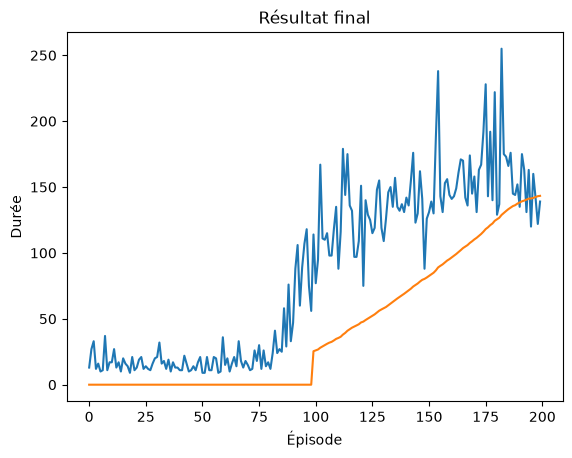

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
# 50 épisodes sur CPU (sans GPU, 600 épisodes prendrait trop longtemps)
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 600
else:
    num_episodes = 200

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        # next_state est None si l'épisode est terminé
        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, next_state, reward)
        state = next_state

        optimize_model()

        # Soft update : θ' ← τ·θ + (1-τ)·θ' — plus stable qu'une copie complète périodique
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = (
                policy_net_state_dict[key] * TAU + target_net_state_dict[key] * (1 - TAU)
            )
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break

print('Entraînement terminé')
plot_durations(show_result=True)
plt.ioff()
plt.show()

**Observations :**

L'entraînement révèle deux phases distinctes : 

- **Épisodes 0 à ~90** : l'agent obtient des durées faibles, entre 10 et 30 pas. Epsilon est encore élevé, l'agent explore majoritairement au hasard et le replay buffer accumule des expériences sans que le réseau ait assez de signal pour apprendre.

- **À partir de l'épisode ~90** : décollage brutal, les durées passent à 150-250 pas en quelques épisodes. Ce saut correspond au moment où epsilon a suffisamment décru, le buffer contient assez d'expériences diversifiées, et les Q-values sont devenues fiables pour guider l'agent.

La moyenne glissante sur 100 épisodes (courbe orange) atteint ~140 en fin d'entraînement, ce qui confirme une progression réelle et non du bruit.

## Entraînement avec Stable-Baselines3

In [9]:
from stable_baselines3 import DQN as DQN_SB3
from stable_baselines3.common.evaluation import evaluate_policy

env_sb3 = gym.make("CartPole-v1")

# MlpPolicy = réseau de neurones dense (Multi-Layer Perceptron)
model = DQN_SB3('MlpPolicy', env_sb3, verbose=1, tensorboard_log="./logs/")

model.learn(total_timesteps=100000)

# Évaluation sur 100 épisodes pour avoir une mesure fiable
mean_reward, std_reward = evaluate_policy(model, env_sb3, n_eval_episodes=100)
print(f"Récompense moyenne : {mean_reward:.2f} +/- {std_reward:.2f}")

model.save("dqn_cartpole")
print("Modèle sauvegardé : dqn_cartpole.zip")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./logs/DQN_2
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20.2     |
|    ep_rew_mean      | 20.2     |
|    exploration_rate | 0.992    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 4756     |
|    time_elapsed     | 0        |
|    total_timesteps  | 81       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 17.6     |
|    ep_rew_mean      | 17.6     |
|    exploration_rate | 0.987    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2018     |
|    time_elapsed     | 0        |
|    total_timesteps  | 141      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.514    |
|    n_updates        | 10       |
-------

/Users/utilisateur/Rapha/ai_engineer/training_rl/.venv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Récompense moyenne : 211.32 +/- 50.39
Modèle sauvegardé : dqn_cartpole.zip


**Observations**

SB3 atteint une récompense moyenne de **211 sur 100 épisodes**, avec un écart-type de 50. Le maximum théorique de CartPole est 500, donc à 211 l'agent maintient le mât debout de façon très fiable.

La perte finale à 0.13 et le taux d'exploration figé à 0.05 indiquent que le réseau a convergé : il exploite presque exclusivement ce qu'il a appris, avec une petite marge d'exploration résiduelle.

L'entraînement a duré 135 secondes à ~735 pas/seconde sur CPU, ce qui confirme que SB3 est bien optimisé pour un usage sans GPU.

## Conclusion

Les deux approches (DQN manuel et Stable-Baselines3) apprennent à jouer à CartPole, mais avec des résultats et des efforts très différents.

| | DQN manuel | SB3 |
|---|---|---|
| Récompense finale | ~140 (moyenne glissante) | 211 (évaluation 100 épisodes) |
| Volume d'entraînement | 200 épisodes | 100 000 pas |
| Temps d'exécution | ~2 min | ~2min15 |
| Lignes de code | ~80 | 3 |

SB3 obtient de meilleurs résultats principalement parce que ses hyperparamètres sont calibrés et que 100 000 pas représentent plus d'expérience que 200 épisodes. 
Avec le même volume d'entraînement, l'écart serait bien plus faible.

L'intérêt du DQN manuel n'est pas de battre SB3. C'est de comprendre ce que SB3 fait sous le capot : le replay buffer, le target network, l'équation de Bellman, la stratégie epsilon-greedy. 

En production, on utilisera toujours SB3 ou une bibliothèque équivalente, mais savoir ce qui se passe à l'intérieur permet de diagnostiquer les problèmes et de faire les bons choix d'algorithme.